1. This dataset is suitable for Linear Regression because the dependent variable (charges) is continous (Topil, 2024). The independent variables (age, BMI, gender of the client, smoking status, number of children and geographic region) have approximately a linear relationship with charges. The dataset size is appropriate for a simple linear regression model.

The dataset used in this analysis was sourced from Kaggle (Mirichoi, 2018)

2.a. Exploratory Data Analysis (EDA)
Exploratory Data Analysis (EDA) is an important step in data analysis that helps in understanding the structure of the dataset, identifying patterns, and detecting anomalies (GeeksforGeeks, 2025). In this dataset, we will check for missing values, review data types, and generate summary statistics. We will visualise using histograms, scatter plots, and box plots to reveal patterns and relationships between different variables.

b. Feature Selection
In order to use our categorical variables (sex, smoker status, and region) in a machine learning algorithm, we need to convert them to numerical data using encoding techniques (SnapWise, 2023). We will conduct a correlation analysis to determine the most relevant features for predicting medical charges.

c. Model Training
We will split the dataset into training and testing sets to assess the model performance on new data (Murmuarpan, 2024)

d. Model Evaluation
We will evaluate our model using metrics such as R^2 score, Mean Absolute Error (MAE), Mean Squared Error (MSE) to measure its effectiveness and predictive performance (ApX Machine Learning, 2026)

e. Reporting
We will write a report to summarise the findings, show data cleaning steps, insights from the analysis, model perfomance and recommendations.

In [27]:
# Importing the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [28]:
# Loading dataset
df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [29]:
# Checking structure
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [30]:
# Checking for missing values
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

3. a.The dataset contains both numerical and categorical variables. There are no missing values, this means that the dataset is clean and ready for analysis.

To show the distribution of medical charges, we will use a histogram. This will help us check whether the data is normally distributed or skewed

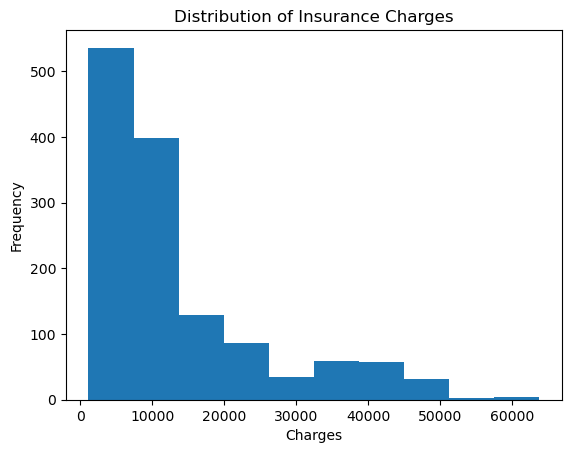

In [31]:
# Visualise distribution of insurance charges
plt.hist(df['charges'])
plt.title("Distribution of Insurance Charges")
plt.xlabel("Charges")
plt.ylabel("Frequency")

# Save the figure as PNG 
plt.savefig('distribution_of_insurance_charges.png', dpi=300)
plt.show()

The distribution of insurance charges is right skewed. This means that a lot of individuals have less charges while a few individuals have higher charges.

To see a relationship between two numeric variables, we will use a scatter plot. That will be for "Age vs Charges" and "BMI vs Charges".

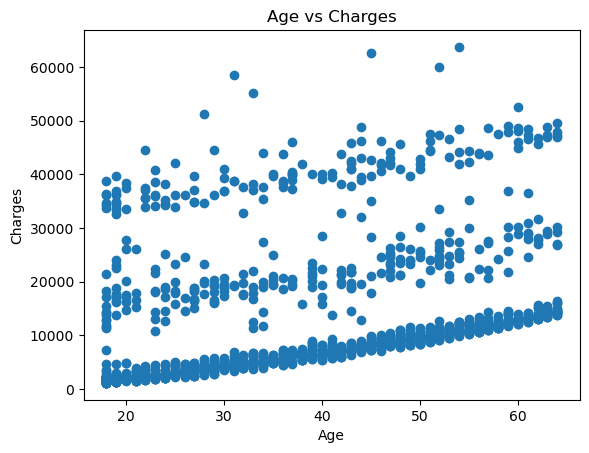

In [32]:
plt.scatter(df['age'], df['charges'])
plt.xlabel("Age")
plt.ylabel("Charges")
plt.title("Age vs Charges")
plt.savefig('age_vs_charges.png', dpi=300)
plt.show()

Younger individuals have lower charges while older individuals have higher charges

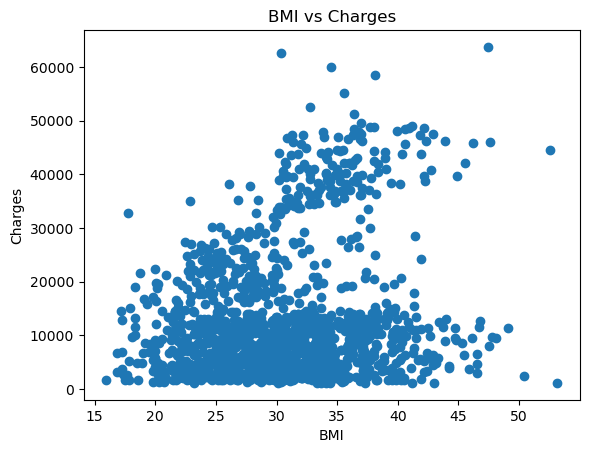

In [33]:
plt.scatter(df['bmi'], df['charges'])
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.title("BMI vs Charges")
plt.savefig('bmi_vs_charges.png', dpi=300)
plt.show()

Individuals with higher BMI have higher charges.

To see a relationship between categorical variables (smokers, sex, and region) vs numeric variable (chaarge), we will use box plot.

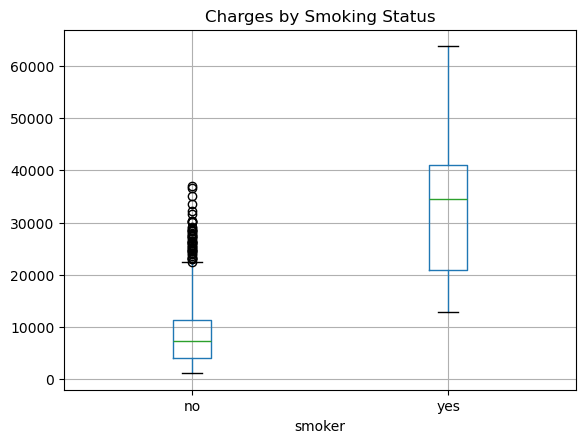

In [34]:
df.boxplot(column='charges', by='smoker')
plt.title("Charges by Smoking Status")
plt.suptitle("")
plt.savefig('charges_by_smoking_status.png', dpi=300)
plt.show()

Individuals who smoke have higher charges while individuals who do not smoke have less charges.

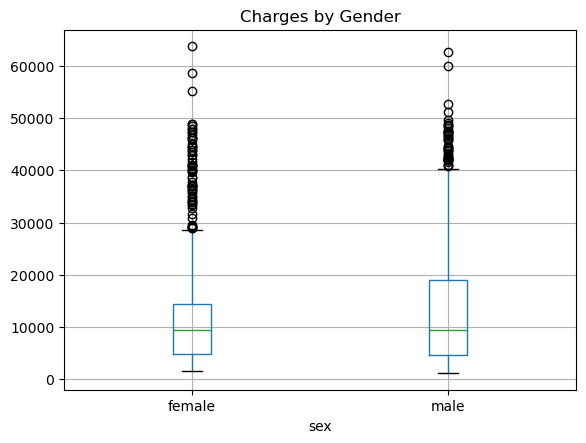

In [35]:
df.boxplot(column='charges', by='sex')
plt.title("Charges by Gender")
plt.suptitle("")
plt.show()

There is no much difference in charges between males and females.

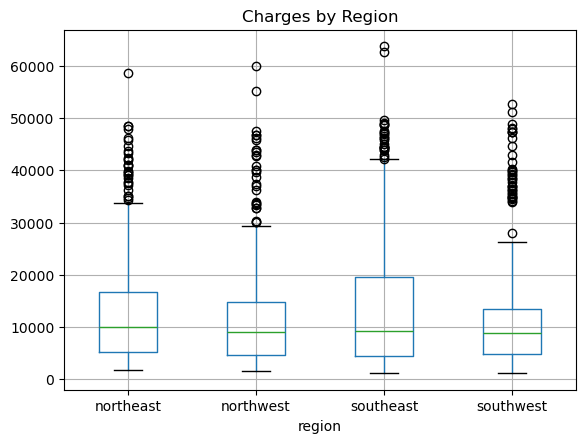

In [36]:
df.boxplot(column='charges', by='region')
plt.title("Charges by Region")
plt.suptitle("")
plt.show()

There is little difference in charges between regions.

In [37]:
# Source: Adapted from Scikit-learn (2024) preprocessing guidelines.
# Convert categorical variables into dummy variables
df = pd.get_dummies(df, drop_first=True)

# Convert True/False to 0/1
df = df.astype(int)

# Define features and target
X = df.drop('charges', axis=1)
y = df['charges']

In this step we converted categorical variables into a numerical format so that they can be used in a machine learning model since machine learning algorithms such as Linear Regression require numerical input. The dataset is also split into:
- Features (X): All independet variables used to make predictions.
- Target variable (y): The dependent variable (charges) that the model aims to predict.

A correlation analysis is conducted to determine the most relevant features for predicting medical charges.

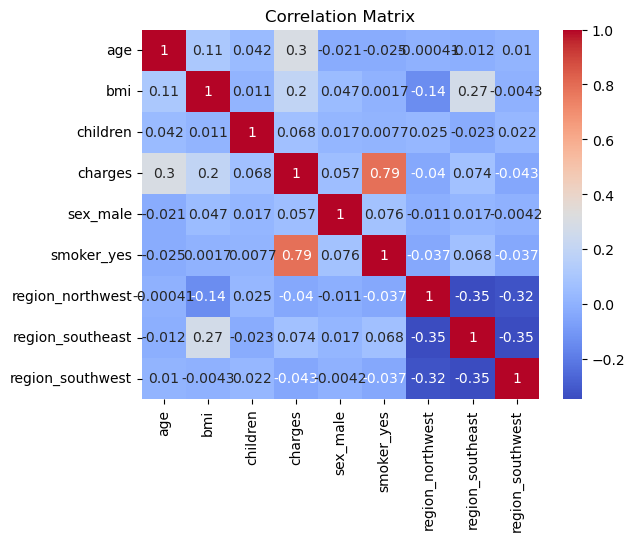

In [38]:
# Correlation matrix
corr_matrix = df.corr(numeric_only=True)

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

The correlation matrix shows that:
- Age has a positive relationship with medical charges.
- BMI has a moderate positive relationship with medical charges.
- Smoker statuus has a strong positive relationship with medical charges.
These results show that smoking status has the most influence on medical charges  followed by age and BMI.

To evaluate the model's performance on unseen data, we will split the dataset into two sets, the training set and the testing set. The training set is used to train the model while the testing set is used to assess its predictive performance. We will use 80/20 split where 80% of the data will be used for training and 20% for testing.

In [39]:
# Splitting the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

A Linear Regression model is used to learn the relationship between the independent variable s and the dependent variable.

In [40]:
# Creating the model
model = LinearRegression()

# Training the model
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


The Linear Regression model has been trained using the training data. In this step, the model learns the relationship between input features and medical charges.

The model coefficients indicate the impact of each feature on the target variable. A positive coefficient shows that the variable increases medical charges while a negative coefficient shows a decrease.

In [41]:
# Displaying coefficients
coeff_df = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
coeff_df
                        

,Coefficient
age,257.096202
bmi,335.633616
children,427.589784
sex_male,-17.262175
smoker_yes,23655.674133
region_northwest,-364.205361
region_southeast,-667.644378
region_southwest,-819.619053


The coefficients show  how each feature have impact on medical charges. Smoking status have the most impact, indicating higher charges.

The intercept represents the predicted value of medical charges when all independent variables are equal to zero.

In [42]:
# Displaying intercept
model.intercept_

np.float64(-11727.706930526096)

The intercept provides the baseline value of medivcal charges when all features are set to zero. This is not always meaningful to real-world interpretation but it is necessary for regrassion equation.

The Linear Regressionmodel implementation is based on standard machine learning practices from Scikit-learn (2024) 

Since we are using a Linear Regression model to predict medical charges (continuous values), the appropriate metrics that we are going to use are Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), AND R^2 score.

In [43]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R^2 Score:", r2)


MAE: 4176.268395299257
MSE: 33566439.73530042
RMSE: 5793.655127404497
R^2 Score: 0.7837888448800693


The model achivied MAE of 4176, this indicates that the predicted values differ from the actual values by approximately 4176. RMSE of 5793, this is larger than MAE so it tells us larger errors exists. The R^2 score of 0.784 which explains about 78.4% of the variation in medical charges. Overall, the model performes well but the difference between MAE and RMSE tells us that the model could be improved.

In [44]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [45]:
from sklearn.linear_model import Ridge

model = Ridge(alpha=1.0)
model.fit(X_train_scaled, y_train)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [46]:
from sklearn.linear_model import Lasso

model = Lasso(alpha=0.1)
model.fit(X_train_scaled, y_train)

,alpha,0.1
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [47]:
# Retraining the model 
y_pred = model.predict(X_test_scaled)

print("New R^2:", r2_score(y_test, y_pred))

New R^2: 0.7837860975880643


After retraining the model using feature scaling and regularization, the R^2 remained almost the same. This shows that the original Linear Regression model was already performing its best on the given features.